**2. MOCO TRAINING**

In [4]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

NOME_PROGETTO = "floods"
project = dh.get_project(NOME_PROGETTO)
print(f"Progetto: {project.name}")

Progetto: floods


**SETUP PARAMETERS**

In [8]:
# Parametri job
job_name = "moco_2D_convLstm_net_v4"                                    # nome da passare poi a notebook moco 
dataset = "Standard"                                                    # Test, Standard, Anomalies*
epochs = 200                                
weights_encoder_sar = "train_sar_2D_convLstm_v1_Standard_200"     
weights_encoder_opt = "train_opt_2D_convLstm_v1_Standard_200"                                        

parametri = {
    "epochs": epochs, 
    "batch_size": 16,
    "lr": 0.005,
    "weight_decay": 1e-4,
    "momentum": 0.9,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,               # sar
    "n_images2": 4, "n_channels2": 10,              # ottico
    "moco_dim": 128,
    "moco_k": 4096,                                   # dimensioni coda (multiplo batch_size),  standard: 4096, test: 64   
    "moco_t": 0.07,
    "symmetric": False,
    "workers": 0,
    "job_name": job_name,
    "dataset": dataset,
    "weights_encoder_sar": weights_encoder_sar,
    "weights_encoder_opt": weights_encoder_opt,
    "patience": 20,
    "min_delta": 1e-4,
    "hidden_channels_dim": 64,
    "simple_proj": False,
    "attn": False,      
    "resume": True,                   
    "time_debug": False                             # time_debug = True solo per debug, = False per training  
}

print(f"PARAMETRI: {parametri}")

# volume
volumi = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "600Gi"}   
    }
]



PARAMETRI: {'epochs': 200, 'batch_size': 16, 'lr': 0.005, 'weight_decay': 0.0001, 'momentum': 0.9, 'patch_size': 256, 'n_images1': 4, 'n_channels1': 2, 'n_images2': 4, 'n_channels2': 10, 'moco_dim': 128, 'moco_k': 4096, 'moco_t': 0.07, 'symmetric': False, 'workers': 0, 'job_name': 'moco_2D_convLstm_net_v4', 'dataset': 'Standard', 'weights_encoder_sar': 'train_sar_2D_convLstm_v1_Standard_200', 'weights_encoder_opt': 'train_opt_2D_convLstm_v1_Standard_200', 'patience': 20, 'min_delta': 0.0001, 'hidden_channels_dim': 64, 'simple_proj': False, 'attn': False, 'resume': True, 'time_debug': False}


**BUILD ENVIRONMENT**

In [9]:
moco_func = project.new_function(
    name= f'moco_Floods_{dataset}_{job_name}_{epochs}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_moco_2D", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2"]
)



# .run("build") -> scarica immagine, installa requirements, copia intera cartella code_src, crea immagine docker

build = moco_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-25 05:51:12,416 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:17,422 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:22,430 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:27,439 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:32,447 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:37,455 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05:51:42,462 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 93668c560fc5468699a963283da54323 to finish...
2026-09-25 05

BUILD: COMPLETED


**TRAINING**

In [ ]:
# action job = avvia container, esegue script, libera risorse

run_moco = moco_func.run(
    action="job", 
    parameters=parametri, 
    volumes=volumi, 
    profile="1xv100-shared",
    # local_execution= True,                       # 1x = 1 gpu
    wait=True
)

print(f"Run moco avviato: {run_moco.id}")
print(run_moco.status.state)
print(run_moco.status.message)

2026-09-25 05:52:07,781 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...


2026-09-25 05:52:12,787 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:17,797 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:22,912 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:28,023 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:33,032 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:38,148 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05:52:43,157 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 80931cc7302a439ebdc41029baaa66b1 to finish...
2026-09-25 05

**PLOTS**

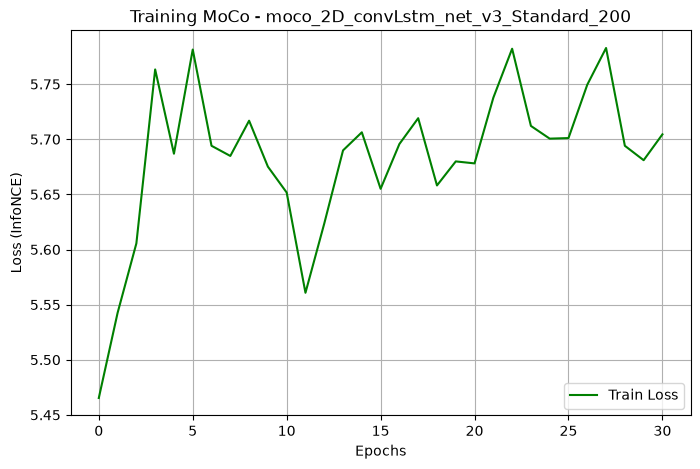

In [ ]:
# salvataggio log
path_moco = project.get_artifact(f"moco-metrics_{job_name}_{dataset}_{epochs}").download(overwrite=True)
df_moco = pd.read_csv(path_moco)

# plot
plt.figure(figsize=(8, 5))
plt.plot(df_moco['epoch'], df_moco['train_loss'], color='green', label='Train Loss')
plt.title(f'Training MoCo - {job_name}_{dataset}_{epochs}')
plt.xlabel('Epochs')
plt.ylabel('Loss (InfoNCE)')
plt.grid(True)
plt.legend()
plt.show()